# Notebook 08 — Graph Neural Network Model

**PharmaLens: An Explainable AI Framework for Drug–Target Interaction Prediction**

---

## Objective

Train a **Graph Neural Network (GNN)** model that operates on molecular graphs directly.

**Why GNNs?** Unlike fingerprints or SMILES strings, molecular graphs preserve the full topology of the molecule. GNNs can learn structural patterns that sequential encodings might miss — ring systems, branching, functional group arrangements.

Architecture:
- **Drug:** SMILES → Molecular Graph → GCN layers → Global Pooling → drug_repr
- **Protein:** Sequence → Embedding → Conv1D → GlobalMaxPool → prot_repr  
- **Fusion:** [drug_repr ⊕ prot_repr] → FC → score

In [1]:
import os, sys, warnings, pickle, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader as PyGDataLoader

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils.config import *
from src.evaluation.metrics import compute_regression_metrics
from src.evaluation.experiment_tracker import ExperimentTracker
from src.models.gnn_model import GraphDTA
from src.models.gnn_dataset import DTIGraphDataset, collate_dti_graphs
from src.training.trainer import Trainer
from src.features.protein_features import encode_sequence

set_seed(42)
COLORS = set_plot_style()
ensure_dirs()
DEVICE = get_device()
tracker = ExperimentTracker()

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print("Setup complete ✓")

Device: cpu
PyTorch: 2.14.0+cpu
Setup complete ✓


## 1. Prepare Graph Data

In [2]:
# Load clean data
df = pd.read_csv(PROCESSED_DATA_DIR / 'kiba_clean.csv')
train_df = pd.read_csv(SPLITS_DIR / 'random_train.csv')
val_df = pd.read_csv(SPLITS_DIR / 'random_val.csv')
test_df = pd.read_csv(SPLITS_DIR / 'random_test.csv')

# Create lookup dicts
drug_smiles_dict = dict(zip(df['drug_id'], df['smiles']))
target_seq_dict = dict(zip(df['target_id'], df['sequence']))

# Encode protein sequences
PROTEIN_MAX_LEN = 1000
target_enc_dict = {tid: encode_sequence(seq, PROTEIN_MAX_LEN) for tid, seq in target_seq_dict.items()}

print(f"Drugs: {len(drug_smiles_dict)}, Targets: {len(target_enc_dict)}")

Drugs: 2111, Targets: 229


In [3]:
# Create PyG datasets (this converts all SMILES to molecular graphs)
print("Building train graph dataset...")
train_dataset = DTIGraphDataset(
    train_df['drug_id'].tolist(), train_df['target_id'].tolist(), train_df['score'].tolist(),
    drug_smiles_dict, target_enc_dict, PROTEIN_MAX_LEN
)

print("Building val graph dataset...")
val_dataset = DTIGraphDataset(
    val_df['drug_id'].tolist(), val_df['target_id'].tolist(), val_df['score'].tolist(),
    drug_smiles_dict, target_enc_dict, PROTEIN_MAX_LEN
)

print("Building test graph dataset...")
test_dataset = DTIGraphDataset(
    test_df['drug_id'].tolist(), test_df['target_id'].tolist(), test_df['score'].tolist(),
    drug_smiles_dict, target_enc_dict, PROTEIN_MAX_LEN
)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Building train graph dataset...
Building val graph dataset...
Building test graph dataset...

Train: 94602 | Val: 11826 | Test: 11826


In [4]:
# Create DataLoaders
BATCH_SIZE = 128

train_loader = PyGDataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=collate_dti_graphs, num_workers=0)
val_loader = PyGDataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            collate_fn=collate_dti_graphs, num_workers=0)
test_loader = PyGDataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             collate_fn=collate_dti_graphs, num_workers=0)

# Inspect a batch
sample_batch = next(iter(train_loader))
print(f"Sample batch:")
print(f"  x (node features): {sample_batch.x.shape}")
print(f"  edge_index: {sample_batch.edge_index.shape}")
print(f"  batch: {sample_batch.batch.shape}")
print(f"  protein_input: {sample_batch.protein_input.shape}")
print(f"  y: {sample_batch.y.shape}")

Sample batch:
  x (node features): torch.Size([3513, 30])
  edge_index: torch.Size([2, 7736])
  batch: torch.Size([3513])
  protein_input: torch.Size([128, 1000])
  y: torch.Size([128])


## 2. Initialize GNN Model

In [5]:
from src.features.mol_graph import get_atom_feature_dim

model = GraphDTA(
    node_feature_dim=get_atom_feature_dim(),
    gnn_hidden_dim=128,
    gnn_output_dim=128,
    gnn_layers=3,
    gnn_type='gcn',
    protein_vocab_size=21,
    protein_embed_dim=128,
    protein_num_filters=32,
    protein_max_len=PROTEIN_MAX_LEN,
    fc_dims=[512, 256],
    dropout=0.2,
)

print(f"Model: GraphDTA (GCN)")
print(f"Parameters: {model.count_parameters():,}")
print(model)

Model: GraphDTA (GCN)
Parameters: 308,065
GraphDTA(
  (drug_encoder): GNNEncoder(
    (convs): ModuleList(
      (0): GCNConv(30, 128)
      (1-2): 2 x GCNConv(128, 128)
    )
    (batch_norms): ModuleList(
      (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (fc_out): Linear(in_features=128, out_features=128, bias=True)
  )
  (protein_encoder): ProteinCNN(
    (embedding): Embedding(22, 128, padding_idx=0)
    (convs): ModuleList(
      (0): Conv1d(128, 32, kernel_size=(4,), stride=(1,), padding=(2,))
      (1): Conv1d(32, 32, kernel_size=(8,), stride=(1,), padding=(4,))
      (2): Conv1d(32, 32, kernel_size=(12,), stride=(1,), padding=(6,))
    )
  )
  (fc_layers): ModuleList(
    (0): Linear(in_features=160, out_features=512, bias=True)
    (1): Linear(in_features=512, out_features=256, bias=True)
  )
  (fc_dropouts): ModuleList(
    (0-1): 2 x Dropout(p=0.2, inplace=False)
  )
  (output): Linear(in_features=256, out_

## 3. Train

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
)

trainer = Trainer(
    model=model,
    optimizer=optimizer,
    criterion=nn.MSELoss(),
    device=DEVICE,
    scheduler=scheduler,
    early_stopping_patience=30,
    checkpoint_dir=GNN_MODELS_DIR,
    model_name='GraphDTA_GCN',
)

EPOCHS = 200
history = trainer.fit(train_loader, val_loader, epochs=EPOCHS, verbose=True)
print(f"\nTotal training time: {trainer.total_training_time:.1f}s")

  Epoch    1/200 | Train: 2.2665 | Val: 2.1905 | LR: 0.000500 | Time: 167.9s
  Epoch   10/200 | Train: 0.9246 | Val: 1.8617 | LR: 0.000500 | Time: 166.7s
  Epoch   20/200 | Train: 0.7918 | Val: 1.3419 | LR: 0.000250 | Time: 166.8s
  Epoch   30/200 | Train: 0.7086 | Val: 1.0965 | LR: 0.000250 | Time: 168.6s
  Epoch   40/200 | Train: 0.6242 | Val: 0.5849 | LR: 0.000250 | Time: 167.3s
  Epoch   50/200 | Train: 0.5473 | Val: 0.3634 | LR: 0.000250 | Time: 167.2s
  Epoch   60/200 | Train: 0.4815 | Val: 0.2932 | LR: 0.000250 | Time: 168.9s
  Epoch   70/200 | Train: 0.4206 | Val: 0.2656 | LR: 0.000250 | Time: 169.1s
  Epoch   80/200 | Train: 0.3783 | Val: 0.2475 | LR: 0.000250 | Time: 171.9s
  Epoch   90/200 | Train: 0.3459 | Val: 0.2307 | LR: 0.000250 | Time: 167.8s
  Epoch  100/200 | Train: 0.3191 | Val: 0.2198 | LR: 0.000250 | Time: 167.2s
  Epoch  110/200 | Train: 0.2964 | Val: 0.2170 | LR: 0.000250 | Time: 174.4s
  Epoch  120/200 | Train: 0.2747 | Val: 0.2086 | LR: 0.000250 | Time: 374.1s

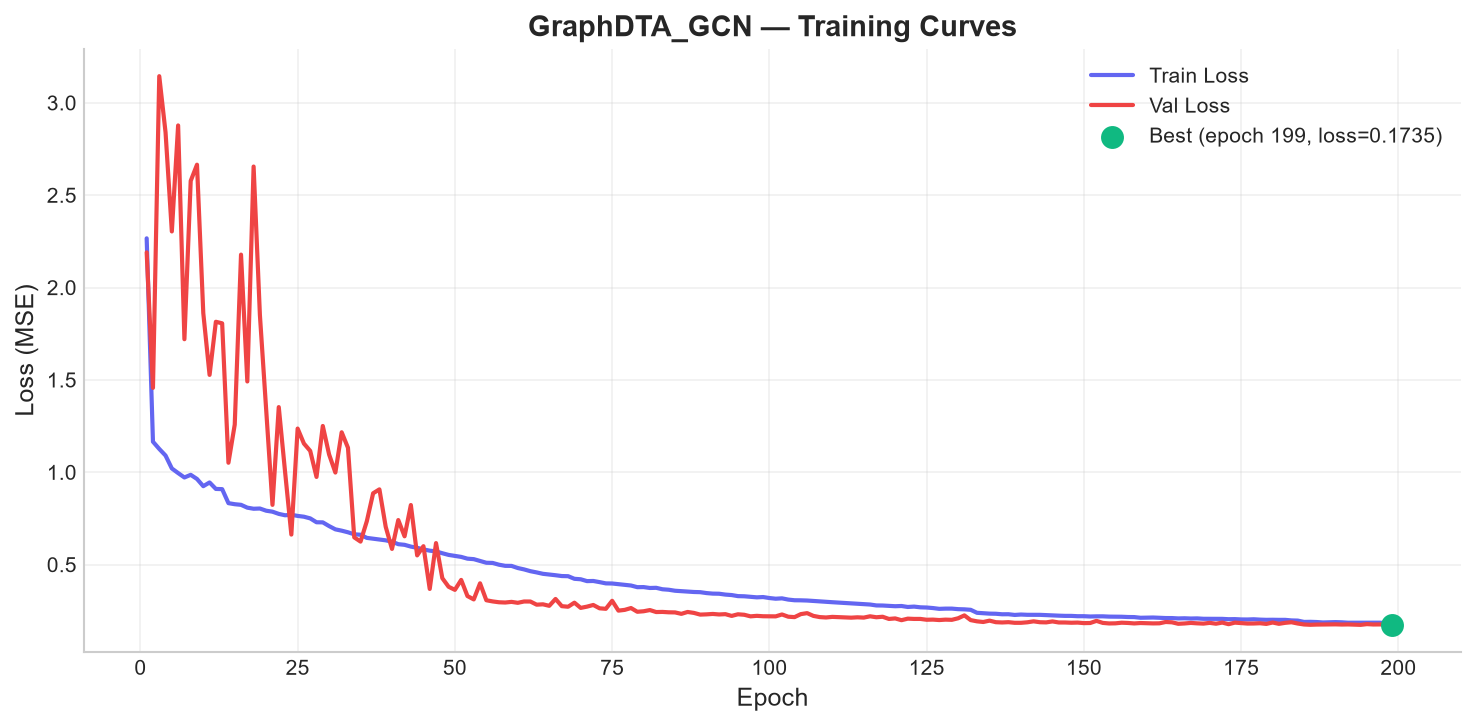

In [7]:
trainer.plot_training_curves(save_path=FIGURES_DIR / 'gnn_training_curves.png')
trainer.save_history(EXPERIMENTS_DIR / 'logs' / 'gnn_history.csv')

## 4. Evaluation

In [8]:
_, y_train_pred, y_train_true = trainer.validate(train_loader)
_, y_val_pred, y_val_true = trainer.validate(val_loader)
_, y_test_pred, y_test_true = trainer.validate(test_loader)

train_metrics = compute_regression_metrics(y_train_true, y_train_pred)
val_metrics = compute_regression_metrics(y_val_true, y_val_pred)
test_metrics = compute_regression_metrics(y_test_true, y_test_pred)

print(f"\n{'='*60}")
print(f"  GraphDTA (GCN) RESULTS")
print(f"{'='*60}")
for split_name, metrics in [('Train', train_metrics), ('Val', val_metrics), ('Test', test_metrics)]:
    print(f"  {split_name:6s} — RMSE: {metrics['rmse']:.4f}  MAE: {metrics['mae']:.4f}  "
          f"Pearson: {metrics['pearson']:.4f}  Spearman: {metrics['spearman']:.4f}  "
          f"R²: {metrics['r2']:.4f}  CI: {metrics['ci']:.4f}")
print(f"{'='*60}")

tracker.log_experiment(
    model='GraphDTA_GCN', dataset='KIBA',
    representation='molecular_graph+seq_encoding',
    split='random', seed=42,
    hyperparameters=model.config,
    metrics=test_metrics,
    training_time=trainer.total_training_time,
)


  GraphDTA (GCN) RESULTS
  Train  — RMSE: 0.3153  MAE: 0.2063  Pearson: 0.9268  Spearman: 0.8945  R²: 0.8583  CI: 0.8883
  Val    — RMSE: 0.4170  MAE: 0.2598  Pearson: 0.8641  Spearman: 0.8395  R²: 0.7457  CI: 0.8563
  Test   — RMSE: 0.4303  MAE: 0.2648  Pearson: 0.8598  Spearman: 0.8403  R²: 0.7382  CI: 0.8561
✓ Logged experiment: EXP_20261001_182059_61f56b | GraphDTA_GCN | random | seed=42


{'experiment_id': 'EXP_20261001_182059_61f56b',
 'timestamp': '2026-10-01T18:20:59.197170',
 'model': 'GraphDTA_GCN',
 'dataset': 'KIBA',
 'representation': 'molecular_graph+seq_encoding',
 'split': 'random',
 'seed': 42,
 'hyperparameters': '{"node_feature_dim": 30, "gnn_hidden_dim": 128, "gnn_output_dim": 128, "gnn_layers": 3, "gnn_type": "gcn", "protein_embed_dim": 128, "protein_num_filters": 32, "fc_dims": [512, 256], "dropout": 0.2}',
 'training_time_sec': 39954.900877952576,
 'inference_time_sec': None,
 'num_parameters': None,
 'notes': '',
 'rmse': 0.4303,
 'mae': 0.2648,
 'mse': 0.1852,
 'pearson': 0.8598,
 'pearson_pvalue': 0.0,
 'spearman': 0.8403,
 'spearman_pvalue': 0.0,
 'r2': 0.7382,
 'ci': np.float64(0.8561),
 'n_samples': 11826}

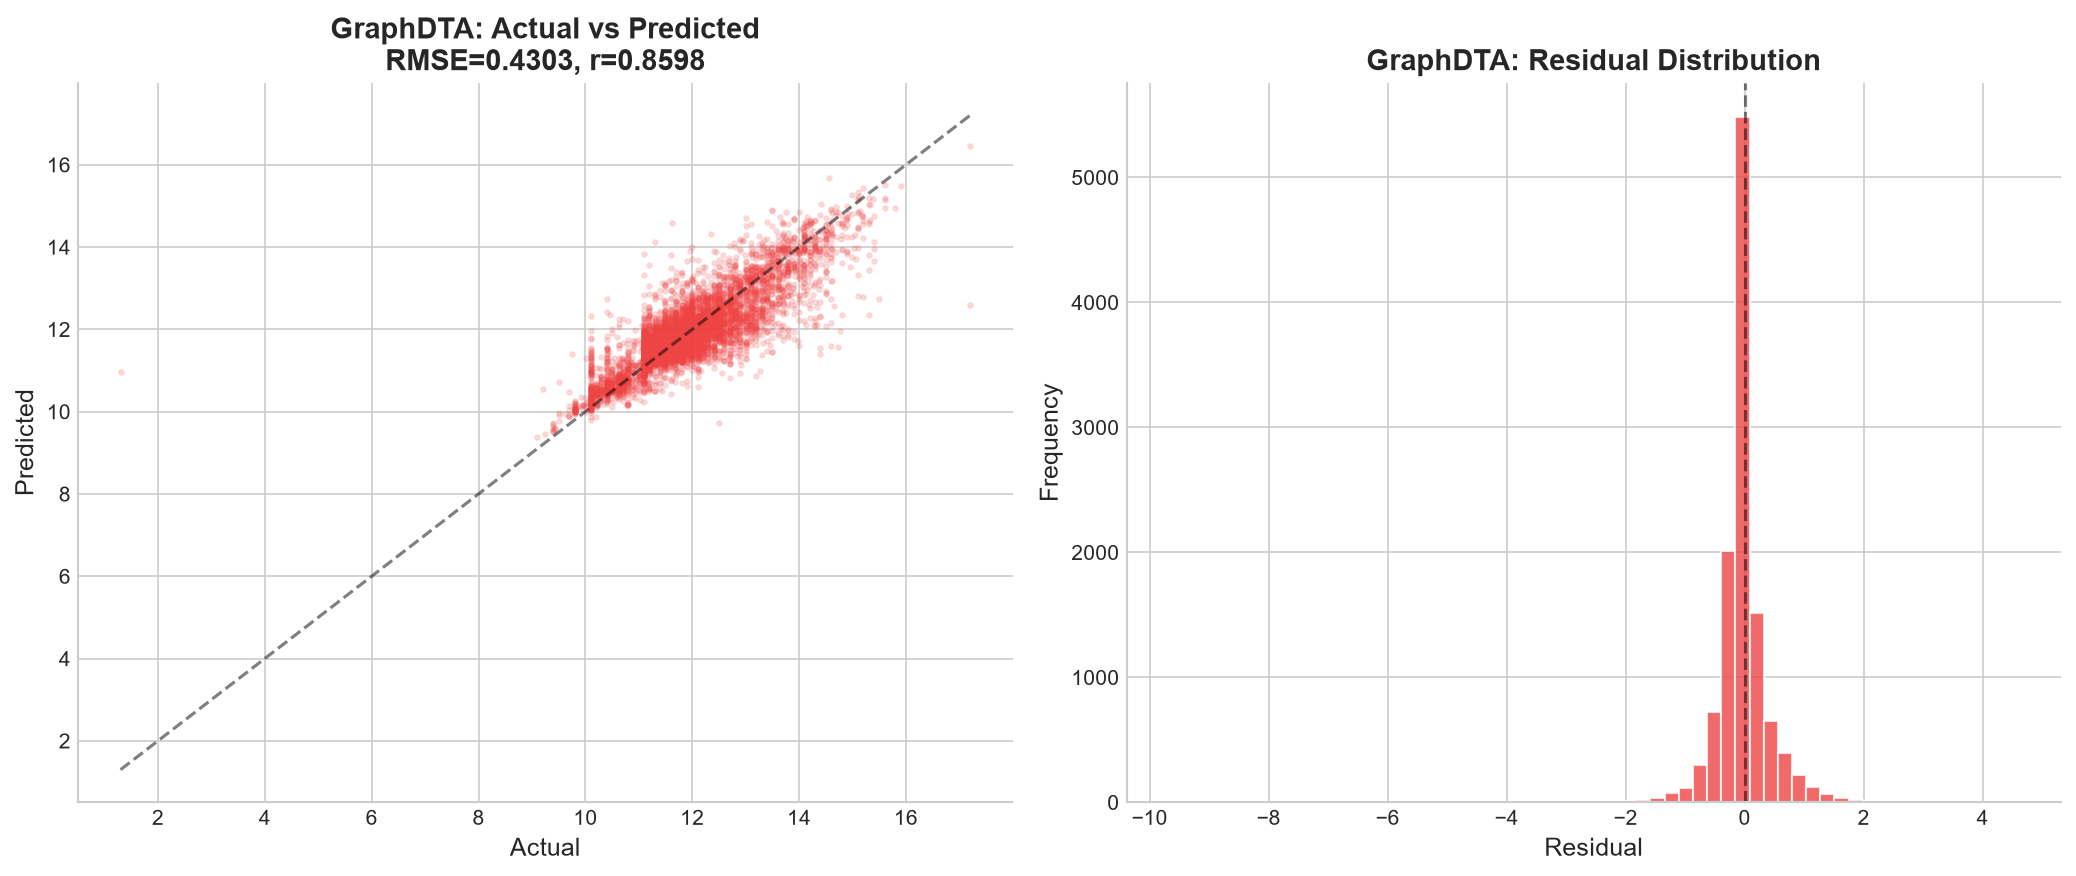

In [9]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test_true, y_test_pred, alpha=0.15, s=5, color=MODEL_COLORS['GNN'])
lims = [min(y_test_true.min(), y_test_pred.min()), max(y_test_true.max(), y_test_pred.max())]
axes[0].plot(lims, lims, 'k--', alpha=0.5)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'GraphDTA: Actual vs Predicted\nRMSE={test_metrics["rmse"]:.4f}, r={test_metrics["pearson"]:.4f}', fontweight='bold')

residuals = y_test_true - y_test_pred
axes[1].hist(residuals, bins=60, color=MODEL_COLORS['GNN'], alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('GraphDTA: Residual Distribution', fontweight='bold')
axes[1].axvline(0, color='k', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gnn_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## Observations

1. **GNN learns from molecular topology** — unlike fingerprints which are fixed hashing, the GNN adaptively learns which substructures matter for binding.

2. **Global pooling** (max + mean) aggregates atom-level representations into a single drug vector. This captures both dominant and average structural features.

3. **Comparison with DeepDTA:** DeepDTA processes SMILES as flat strings; GNN processes the actual molecular graph. The difference in performance reveals whether topology awareness helps.

## Conclusion

GraphDTA has been trained and evaluated. All results are logged. The next step is to compare all models head-to-head.

**Next:** [Notebook 09 — Model Comparison](./09_model_comparison.ipynb)